<a href="https://colab.research.google.com/github/apaulag24/ED2-PF-202510/blob/main/openreturn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción y contexto
 *falta detallar la intro y el contexto*

 El objetivo de este Análisis Exploratorio de Datos (EDA) es examinar el comportamiento histórico del precio de la acción de Microsoft (MSFT), identificar patrones temporales, evaluar su estructura estadística y analizar la dinámica de la volatilidad a lo largo del período 2000–2026.

In [82]:
# Instalar Yahoo Finance
!pip install yfinance

# Importar librerías
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings("ignore")


# Descripción del dataset (dimensiones, variables, tipos de datos)
Se descargan los datos históricos de Microsoft desde el año 2000 yfinance genera un MultiIndex en las columnas (variable + ticker),
por lo que se elimina el segundo nivel para simplificar el acceso.

In [16]:
sns.set_style("darkgrid")

In [17]:
ticker = 'MSFT'
dfmicrosoft = yf.download(ticker, start="2000-01-01")
dfmicrosoft.columns = dfmicrosoft.columns.droplevel(1)  # Elimina nivel del ticker
print('Column names: ', dfmicrosoft.columns)
dfmicrosoft.head()

[*********************100%***********************]  1 of 1 completed

Column names:  Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


Price,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,35.520374,36.148885,34.130033,35.767969,53228400
2000-01-04,34.320480,35.691776,34.206206,34.606167,54119000
2000-01-05,34.682354,35.463231,33.330104,33.863386,64059600
2000-01-06,33.520573,34.701411,33.025382,34.187175,54976600
2000-01-07,33.958626,34.206221,32.701604,33.101566,62013600


Para obtener una idea del tamaño de los datos en número de filas y columnas ejecutamos la siguiente línea

In [18]:
print('No. of rows, columns:', dfmicrosoft.shape)

No. of rows, columns: (6578, 5)


El conjunto de datos descargado contiene 6.578 observaciones (filas) y 5 variables (columnas).

Las 6.578 filas representan registros diarios del comportamiento de la acción de Microsoft desde el 1 de enero del año 2000 hasta la fecha de descarga de los datos. Es decir, cada fila corresponde a un día de negociación en el mercado bursátil.

Las 5 columnas corresponden a las variables financieras fundamentales: precio de apertura (Open), precio máximo (High), precio mínimo (Low), precio de cierre (Close) y volumen de transacciones (Volume).

En conjunto, el tamaño del dataset indica que se dispone de una serie temporal extensa, con más de dos décadas de información diaria, lo que resulta adecuado para realizar un análisis exploratorio robusto y estudiar la evolución histórica y la volatilidad de la acción en el largo plazo.

In [19]:
dfmicrosoft.isna().sum()

,0
Price,
Close,0
High,0
Low,0
Open,0
Volume,0


Por lo anterior, podemos confirmar que no hay valores faltantes.

In [20]:
dfmicrosoft.dtypes

,0
Price,
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64


El análisis de los tipos de datos (dtypes) muestra que las variables de precios (Open, High, Low y Close) están almacenadas como float64, lo que indica que son variables numéricas continuas con decimales. Esto es consistente con la naturaleza de los precios financieros, que pueden tomar valores con alta precisión decimal.

Por otro lado, la variable Volume está registrada como int64, lo que significa que representa valores enteros. Esto es coherente con su definición, ya que el volumen corresponde al número total de acciones negociadas en cada jornada y, por tanto, no puede tomar valores fraccionarios.

En términos generales, la estructura de los tipos de datos es adecuada para realizar cálculos financieros, tales como rendimientos, desviaciones estándar y otras medidas estadísticas necesarias para el análisis de volatilidad.
La variable fecha no aparece dentro de data.dtypes porque no es una columna, sino el índice del DataFrame. Por lo tanto, para conocer su tipo de dato se debe consultar el tipo del índice.

Se puede verificar con:

In [21]:
type(dfmicrosoft.index)

pandas.core.indexes.datetimes.DatetimeIndex

La fecha está almacenada como un DatetimeIndex (datetime64[ns]), lo que confirma que el conjunto de datos está estructurado como una serie temporal. Esto es fundamental para el análisis de volatilidad, ya que permite realizar operaciones basadas en el tiempo, como cálculos de rendimientos diarios, agregaciones mensuales o análisis por periodos específicos.

In [22]:
# Extraer variables clave para el análisis de volatilidad
close_series = dfmicrosoft[['Close']]           # Precio de cierre
close_series.columns = ['Close']       # Renombra la columna para facilitar su acceso
close_series




,Close
Date,
2000-01-03,35.520374
2000-01-04,34.320480
2000-01-05,34.682354
2000-01-06,33.520573
2000-01-07,33.958626
...,...
2026-02-23,384.470001
2026-02-24,389.000000
2026-02-25,400.600006


En particular, para el análisis de volatilidad y rendimientos será fundamental trabajar con la columna Close, ya que el precio de cierre es la variable estándar utilizada en estudios financieros para calcular variaciones porcentuales y medir riesgo.

Antes de proceder con los gráficos y cálculos correspondientes, es conveniente verificar que la columna Close esté presente en el conjunto de datos. Esto se puede comprobar inspeccionando los nombres de las columnas del DataFrame.

Realizar esta validación previa garantiza que los análisis posteriores —como el cálculo de rendimientos diarios o la estimación de la volatilidad— se ejecuten correctamente y sobre la variable adecuada.

# Estadísticas descriptivas

In [23]:
close_series.describe()

,Close
count,6578.000000
mean,101.007925
std,132.559089
min,11.113187
25%,18.987725
50%,25.980844
75%,129.123402
max,539.825195


Las estadísticas descriptivas del precio de cierre (Close) se calculan sobre 6.578 observaciones diarias, lo que confirma la amplitud temporal del conjunto de datos.

El precio promedio de cierre durante el período analizado es de 101,01 USD, mientras que la desviación estándar es de 132,56 USD, un valor elevado en relación con la media. Esto indica una alta dispersión de los precios y, por tanto, una variabilidad considerable a lo largo del tiempo.

El valor mínimo registrado fue de 11,11 USD, mientras que el máximo alcanzó 539,83 USD, lo que evidencia un crecimiento significativo de la acción en el largo plazo.

En cuanto a la distribución:

El 25% de los precios se sitúa por debajo de 18,99 USD.

La mediana (50%) es 25,98 USD.

El 75% de las observaciones está por debajo de 129,12 USD.

La diferencia marcada entre la mediana y la media sugiere la presencia de asimetría positiva (sesgo a la derecha), causada por los valores altos registrados en los años más recientes. En conjunto, estos resultados reflejan una tendencia creciente de largo plazo acompañada de una alta variabilidad, elementos fundamentales en el análisis de la volatilidad histórica de la acción.

In [24]:
close_series.head()

,Close
Date,
2000-01-03,35.520374
2000-01-04,34.320480
2000-01-05,34.682354
2000-01-06,33.520573
2000-01-07,33.958626


Se observa que el precio de cierre el 03/01/2000 fue de 35,52 USD, seguido de una disminución el 04/01/2000 a 34,32 USD. Posteriormente, el precio presenta ligeras fluctuaciones en los días siguientes, con movimientos tanto positivos como negativos.

Este comportamiento inicial evidencia que el precio de la acción experimenta variaciones diarias constantes, lo cual es característico de los mercados financieros. Además, confirma que la serie está correctamente indexada por fecha, lo que permite analizar la evolución temporal del activo y calcular posteriormente los retornos diarios para el estudio de la volatilidad.

In [25]:
close_series.tail()

,Close
Date,
2026-02-23,384.470001
2026-02-24,389.000000
2026-02-25,400.600006
2026-02-26,401.720001
2026-02-27,392.739990


In [26]:
# ── Estadísticas Descriptivas ──────────────────────────────────
Q1 = close_series.quantile(0.25)
Q3 = close_series.quantile(0.75)
IQR = Q3 - Q1

estadisticas = pd.DataFrame({
    'Media':                close_series.mean(),
    'Mediana':              close_series.median(),
    'Desv. Estándar':       close_series.std(),
    'Mínimo':               close_series.min(),
    'Máximo':               close_series.max(),
    'Q1 (25%)':             Q1,
    'Q3 (75%)':             Q3,
    'IQR (Q3-Q1)':          IQR,
    'Asimetría':            close_series.skew(),
    'Curtosis':             close_series.kurt()
}).T.round(4)

print("ESTADÍSTICAS DESCRIPTIVAS — MSFT")
display(estadisticas)

ESTADÍSTICAS DESCRIPTIVAS — MSFT


,Close
Media,101.0079
Mediana,25.9808
Desv. Estándar,132.5591
Mínimo,11.1132
Máximo,539.8252
Q1 (25%),18.9877
Q3 (75%),129.1234
IQR (Q3-Q1),110.1357
Asimetría,1.6119
Curtosis,1.3751


El precio promedio histórico de la acción de Microsoft es 101.01 USD, lo que refleja el nivel medio al que ha cotizado la acción durante el período analizado. Sin embargo, más allá del promedio, resulta fundamental analizar la dispersión de los datos. El rango intercuartílico (IQR = 110.14 USD) indica que el 50% central de los precios históricos se concentra en un intervalo de 110.14 USD entre el primer y el tercer cuartil. Este valor elevado evidencia una amplia variación en los niveles del precio a lo largo del tiempo. Desde una perspectiva económica, esta dispersión está asociada principalmente al crecimiento estructural de la acción en el largo plazo, ya que Microsoft ha pasado de cotizar en niveles bajos a comienzos de la década del 2000 a valores significativamente más altos en años recientes.

Por otro lado, al analizar los retornos diarios, la desviación estándar es 0.0189 (1.89%), lo que significa que, en promedio, el precio de Microsoft fluctúa aproximadamente un 1.89% diario respecto al día anterior. Esta medida representa directamente la volatilidad diaria del activo y constituye una aproximación al riesgo asociado a la inversión. El IQR de los retornos (0.0174) muestra que el 50% central de las variaciones diarias se encuentra dentro de un rango relativamente moderado (1.74%), lo que indica que en condiciones normales los movimientos diarios no suelen ser extremos. Sin embargo, la diferencia entre el IQR y la desviación estándar sugiere la presencia de eventos atípicos o movimientos bruscos que incrementan la dispersión total, fenómeno característico de los mercados financieros y fundamental en el análisis de volatilidad.

# Visualización de la serie

### Visualización temporal

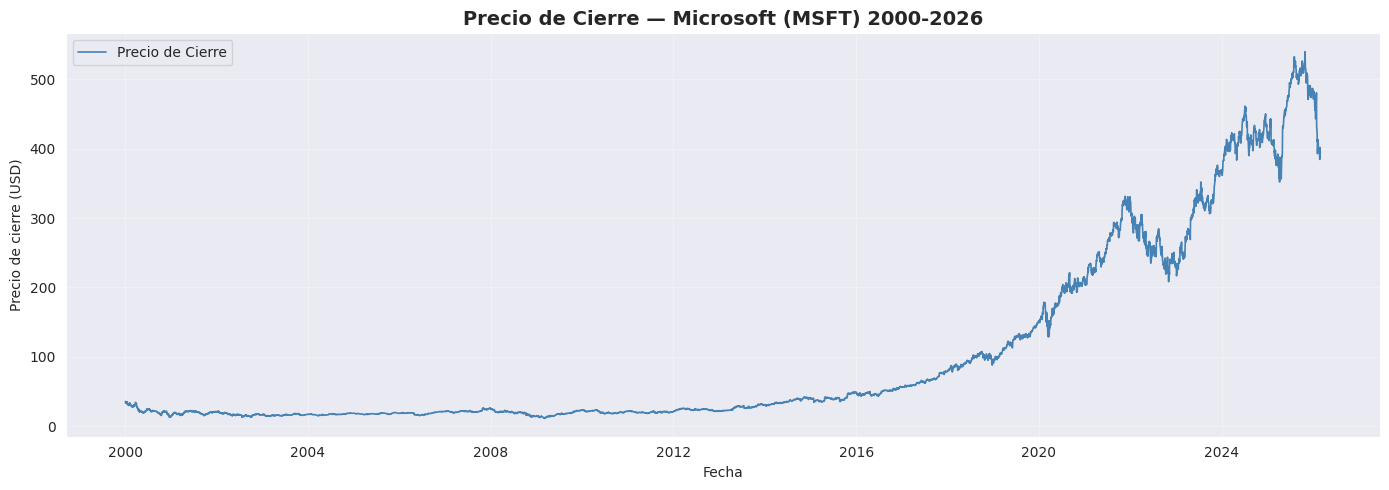

In [27]:
# Filtrar filas donde Close no sea nulo
df_plot = close_series.loc[~pd.isnull(close_series['Close']), :]

# Fechas dinámicas
year_inicio = df_plot.index.min().year
year_fin = df_plot.index.max().year

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_plot.index, df_plot['Close'], color='steelblue', linewidth=1.2, label='Precio de Cierre')

ax.set_title(f'Precio de Cierre — Microsoft (MSFT) {year_inicio}-{year_fin}', fontsize=14, fontweight='bold')
ax.set_ylabel('Precio de cierre (USD)')
ax.set_xlabel('Fecha')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

La gráfica muestra la evolución histórica del precio de cierre de la acción de Microsoft desde el año 2000 hasta 2026. Se observa claramente una tendencia creciente de largo plazo, especialmente marcada a partir de 2013–2014, donde el precio inicia una fase de expansión sostenida.

Durante los primeros años (2000–2010), el precio se mantiene relativamente estable, con fluctuaciones moderadas y sin una tendencia pronunciada. Posteriormente, se identifica un cambio estructural en la dinámica del activo, caracterizado por un crecimiento acelerado que lleva el precio desde niveles cercanos a 30–40 USD hasta superar los 500 USD en años recientes.

También se observan episodios de caídas significativas y correcciones temporales, como en periodos de alta incertidumbre del mercado, lo que evidencia que, aunque la tendencia general es alcista, el activo experimenta fases de alta volatilidad.

Desde el punto de vista estadístico, la serie en niveles no parece estacionaria, ya que presenta una tendencia clara y cambios en la varianza a lo largo del tiempo. Esto justifica la necesidad de trabajar con retornos en lugar de precios para el análisis de volatilidad.

### Visualización de los retornos

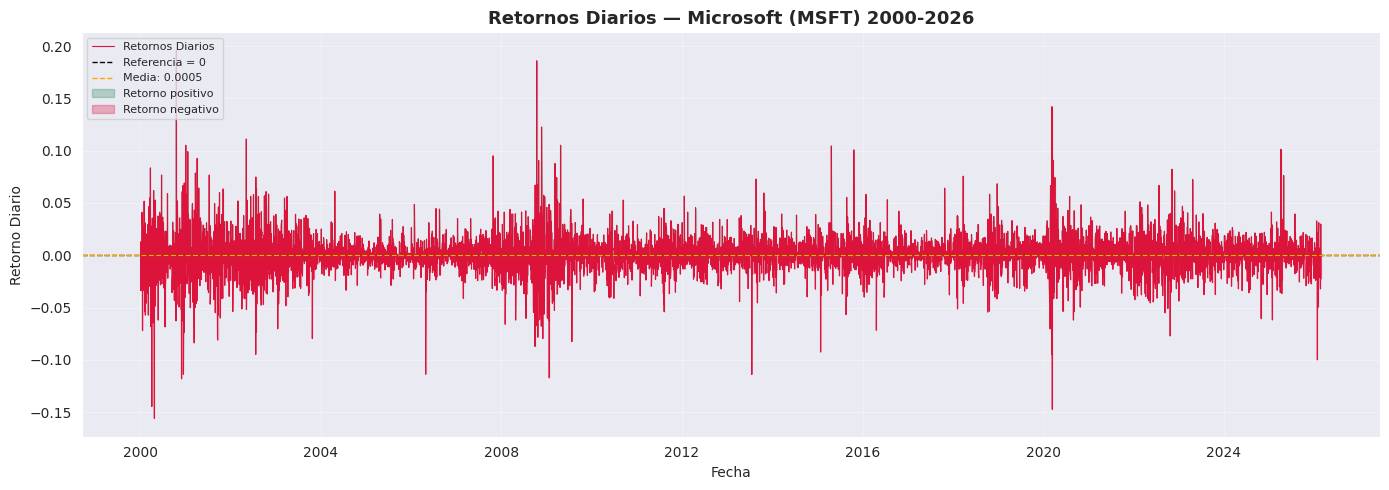

In [30]:
# Calcular returns si no existen
close_series['Returns'] = close_series['Close'].pct_change()

# Convertir a arrays numpy
close_np = np.array(close_series['Close'].dropna())
returns_np = np.array(close_series['Returns'].dropna())
# Gráfico de retornos en el tiempo
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(close_series.index, close_series['Returns'],
        color='crimson', linewidth=0.8, label='Retornos Diarios')

ax.axhline(0, color='black', linestyle='--', linewidth=1.0, label='Referencia = 0')
ax.axhline(close_series['Returns'].mean(), color='orange', linestyle='--',
           linewidth=1.0, label=f"Media: {close_series['Returns'].mean():.4f}")

ax.fill_between(close_series.index, close_series['Returns'], 0,
                where=close_series['Returns'] >= 0, color='seagreen', alpha=0.3, label='Retorno positivo')
ax.fill_between(close_series.index, close_series['Returns'], 0,
                where=close_series['Returns'] < 0, color='crimson', alpha=0.3, label='Retorno negativo')

ax.set_title(f'Retornos Diarios — Microsoft (MSFT) {year_inicio}-{year_fin}',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Retorno Diario')
ax.set_xlabel('Fecha')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

La gráfica muestra el comportamiento de los retornos diarios de la acción de Microsoft a lo largo del período 2000–2026. Se observa que los retornos fluctúan alrededor de cero, lo que indica que no existe una tendencia determinística en las variaciones porcentuales, a diferencia del precio en niveles.

Un aspecto fundamental que se evidencia en la gráfica es el clustering de volatilidad: los movimientos de gran magnitud tienden a agruparse en ciertos períodos específicos. Es decir, fases de alta volatilidad (con retornos extremos positivos y negativos) son seguidas por otros días igualmente volátiles, mientras que existen intervalos prolongados donde los retornos son relativamente pequeños y estables.

También se identifican episodios de retornos extremos tanto positivos como negativos, algunos superiores al ±10%, lo que refleja la presencia de shocks de mercado o eventos de alta incertidumbre. Estos eventos contribuyen significativamente a la dispersión total de la serie y son característicos de los activos financieros.

Desde el punto de vista estadístico, la serie de retornos parece oscilar alrededor de una media cercana a cero y presenta variabilidad cambiante en el tiempo (heterocedasticidad), lo cual justifica el análisis detallado de la volatilidad y posibles modelos dinámicos para su estimación.


### Distribución

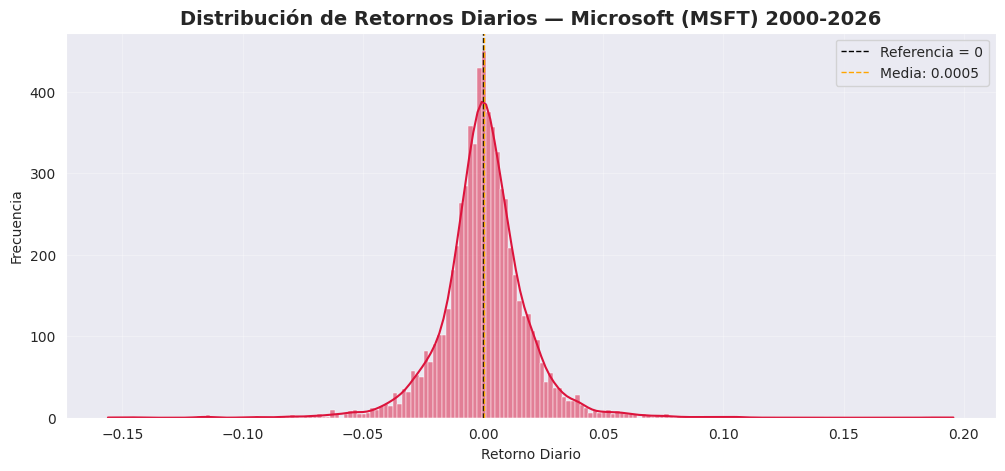

In [32]:
# Calcular returns si no existen
close_series['Returns'] = close_series['Close'].pct_change()

# Convertir a arrays numpy
close_np = np.array(close_series['Close'].dropna())
returns_np = np.array(close_series['Returns'].dropna())

# ── Distribución de los Retornos ───────────────────────────────
plt.figure(figsize=(12, 5))
g = sns.histplot(returns_np, kde=True, color='crimson')
g.set_title(f'Distribución de Retornos Diarios — Microsoft (MSFT) {year_inicio}-{year_fin}',
            fontsize=14, fontweight='bold')
plt.xlabel('Retorno Diario')
plt.ylabel('Frecuencia')
# Línea de referencia en cero
plt.axvline(0, color='black', linestyle='--', linewidth=1.0, label='Referencia = 0')
plt.axvline(close_series['Returns'].mean(), color='orange', linestyle='--',
            linewidth=1.0, label=f"Media: {close_series['Returns'].mean():.4f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

La distribución de los retornos diarios muestra que la mayoría de las variaciones porcentuales se concentran alrededor de cero, lo cual es consistente con el comportamiento típico de los activos financieros: en la mayoría de los días los movimientos son relativamente pequeños.

La media aproximada de 0.0005 (0.05%) indica que, en promedio, la acción presenta un rendimiento diario ligeramente positivo en el largo plazo. Sin embargo, la media es muy cercana a cero en comparación con la dispersión, lo que sugiere que el comportamiento diario está dominado por la volatilidad más que por la tendencia.

La forma de la distribución es aproximadamente simétrica alrededor de cero, pero presenta colas pronunciadas (colas gruesas). Esto implica que la probabilidad de observar movimientos extremos es mayor que la que predeciría una distribución normal. En otras palabras, existen retornos muy grandes —tanto positivos como negativos— que ocurren con mayor frecuencia de lo que asumiría un modelo gaussiano.

Además, el pico central es relativamente alto, lo que indica una fuerte concentración de observaciones cerca de la media, mientras que las colas extendidas reflejan eventos de alta incertidumbre o shocks de mercado.

Desde el punto de vista financiero, este comportamiento es característico de las series de retornos y sugiere:

Presencia de leptocurtosis (colas pesadas).

Alta concentración de valores cercanos a cero.

Existencia de eventos extremos que incrementan el riesgo.

No normalidad de la distribución.

En consecuencia, la gráfica confirma que la volatilidad no es constante y que los retornos presentan episodios extremos que deben ser considerados en cualquier análisis de riesgo o modelación estadística.

## Análisis de componentes

### Descomposición clásica

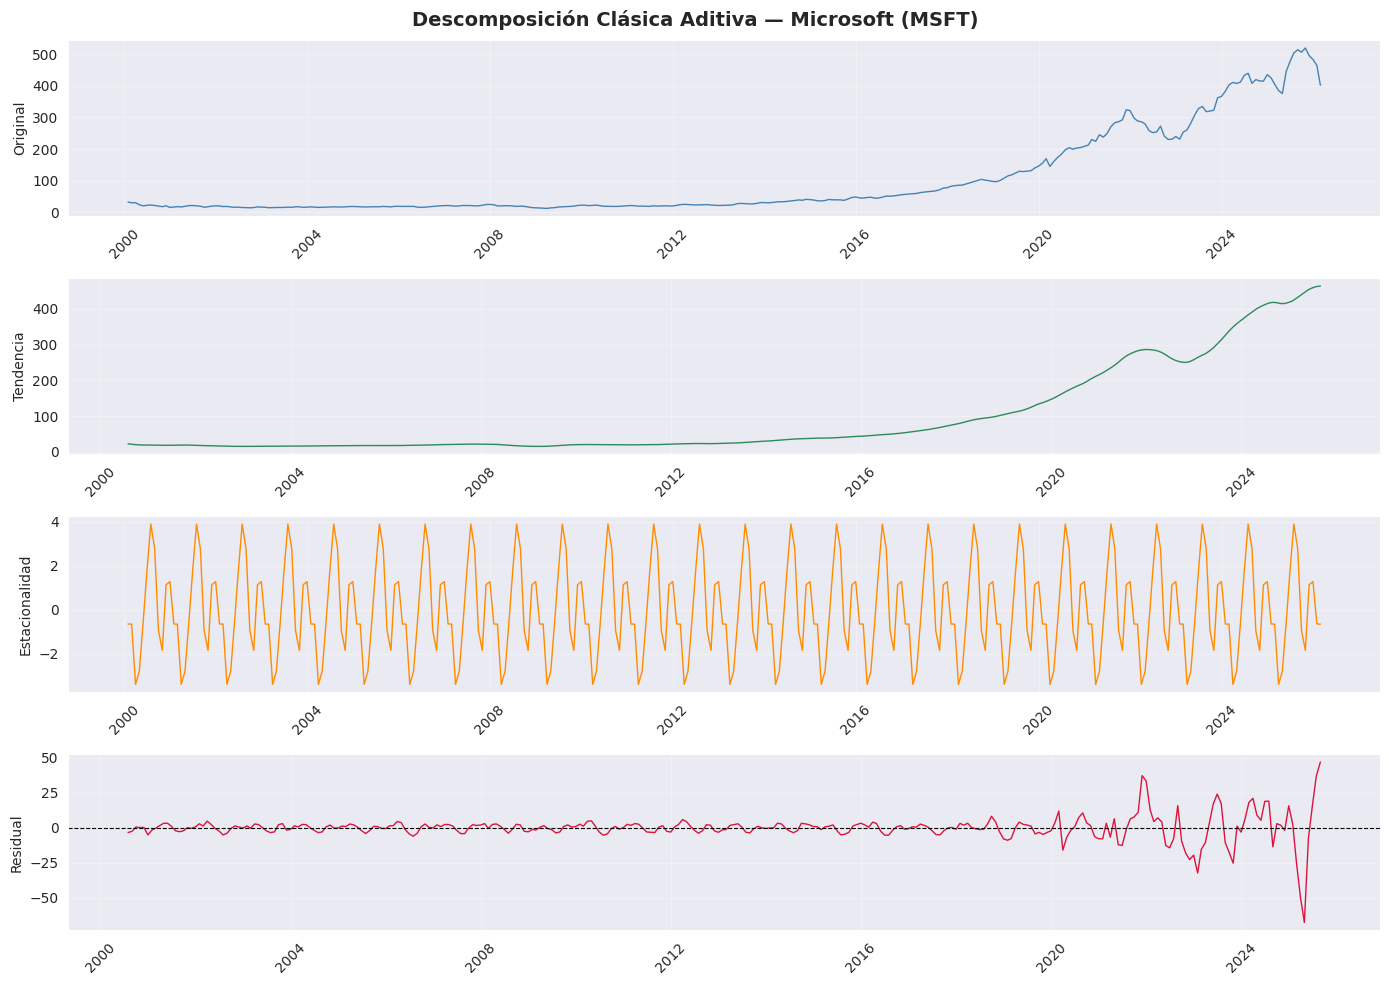

In [47]:
# Usamos Close para la descomposición
# Resampleamos a frecuencia mensual para que la estacionalidad sea más clara
serie = close_series['Close'].resample('ME').mean().dropna()

# ── Descomposición Clásica Aditiva ─────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
fig.suptitle('Descomposición Clásica Aditiva — Microsoft (MSFT)',
             fontsize=14, fontweight='bold')

decomp_add = seasonal_decompose(serie, model='additive', period=12)

axes[0].plot(decomp_add.observed, color='steelblue', linewidth=1.0)
axes[0].set_ylabel('Original')
axes[0].grid(True, alpha=0.3)

axes[1].plot(decomp_add.trend, color='seagreen', linewidth=1.0)
axes[1].set_ylabel('Tendencia')
axes[1].grid(True, alpha=0.3)

axes[2].plot(decomp_add.seasonal, color='darkorange', linewidth=1.0)
axes[2].set_ylabel('Estacionalidad')
axes[2].grid(True, alpha=0.3)

axes[3].plot(decomp_add.resid, color='crimson', linewidth=1.0)
axes[3].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[3].set_ylabel('Residual')
axes[3].grid(True, alpha=0.3)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



Con el objetivo de analizar la estructura interna de la serie temporal del precio de cierre diario de Microsoft (MSFT), se aplicó un análisis clásico bajo un esquema aditivo (Dujmovic, 2025). Este procedimiento separa la serie en tres componentes fundamentales —tendencia, estacionalidad y residuales— bajo el supuesto de fluctuaciones estacionales de magnitud constante, representada como Y_t = T_t + S_t + R_t (Jensen et al., 2018).

La serie evidencia no estacionariedad con tendencia creciente acelerada desde 2013-2015 y volatilidad creciente post-2019, confirmando heterocedasticidad en residuales típica de series financieras (Dujmovic, 2025; Jensen et al., 2018).
Esta prueba contrasta la hipótesis nula
𝐻_0 de presencia de raíz unitaria (serie no estacionaria) frente a la hipótesis alternativa de estacionariedad.

Para la serie de Precio de Cierre (Close), el estadístico ADF fue 0.7140 con un p-valor de 0.9901. Dado que el p-valor es ampliamente superior al nivel de significancia del 5%, no se rechaza la hipótesis nula. Además, el estadístico ADF es mayor (menos negativo) que todos los valores críticos reportados (1%, 5% y 10%), lo que confirma que la serie presenta raíz unitaria. En consecuencia, el precio de cierre no es estacionario en nivel. Este resultado es consistente con el análisis gráfico previo, donde se observó una tendencia creciente de largo plazo y cambios en la media a lo largo del tiempo.

En contraste, para la serie de Retornos Diarios (Returns), el estadístico ADF fue -28.0644 con un p-valor prácticamente igual a 0.0000. En este caso, el p-valor es menor que 0.05, por lo que se rechaza la hipótesis nula de raíz unitaria. Adicionalmente, el estadístico es mucho más negativo que los valores críticos, lo que proporciona evidencia contundente de estacionariedad. Esto indica que la serie de retornos no presenta tendencia determinística ni raíz unitaria, y que sus fluctuaciones se mantienen alrededor de una media constante.

En conjunto, los resultados confirman un comportamiento típico de series financieras: los precios en niveles no son estacionarios, mientras que sus retornos sí lo son. Este hallazgo justifica el uso de los retornos para el modelamiento econométrico y el análisis de volatilidad, ya que la mayoría de los modelos de series de tiempo requieren estacionariedad para producir inferencias válidas.

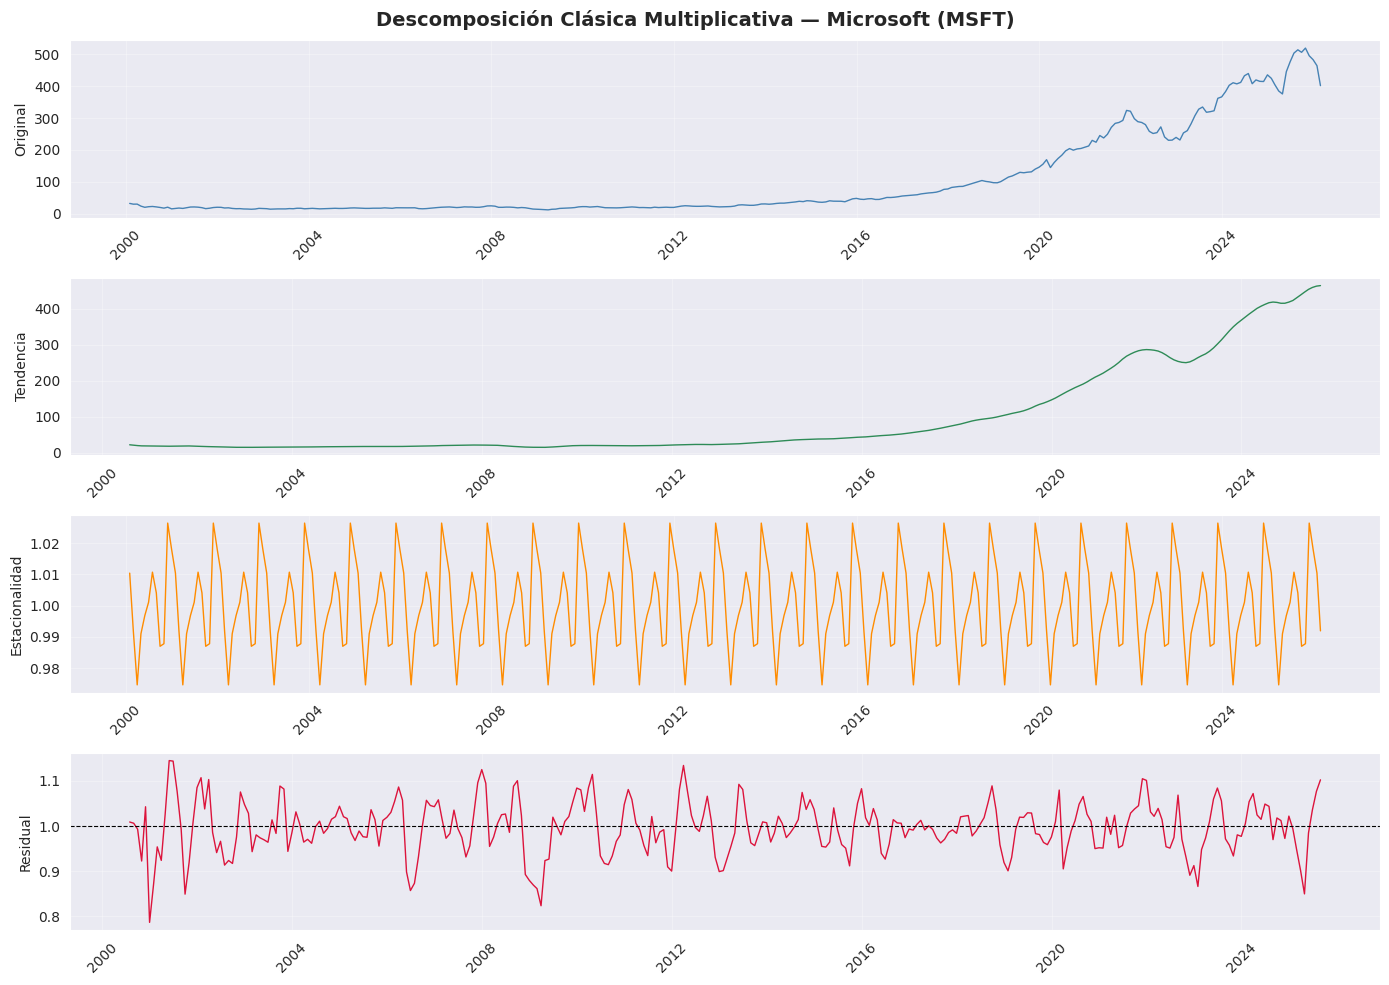

In [48]:
# ── Descomposición Clásica Multiplicativa ──────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
fig.suptitle('Descomposición Clásica Multiplicativa — Microsoft (MSFT)',
             fontsize=14, fontweight='bold')

decomp_mul = seasonal_decompose(serie, model='multiplicative', period=12)

axes[0].plot(decomp_mul.observed, color='steelblue', linewidth=1.0)
axes[0].set_ylabel('Original')
axes[0].grid(True, alpha=0.3)

axes[1].plot(decomp_mul.trend, color='seagreen', linewidth=1.0)
axes[1].set_ylabel('Tendencia')
axes[1].grid(True, alpha=0.3)

axes[2].plot(decomp_mul.seasonal, color='darkorange', linewidth=1.0)
axes[2].set_ylabel('Estacionalidad')
axes[2].grid(True, alpha=0.3)

axes[3].plot(decomp_mul.resid, color='crimson', linewidth=1.0)
axes[3].axhline(1, color='black', linestyle='--', linewidth=0.8)
axes[3].set_ylabel('Residual')
axes[3].grid(True, alpha=0.3)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Con el propósito de analizar la estructura interna de la serie temporal correspondiente al precio de cierre diario de Microsoft (MSFT), se aplicó un análisis clásico bajo un esquema multiplicativo (Dujmovic, 2025). Este método permite separar la serie en tres componentes fundamentales —tendencia, estacionalidad y residuales— asumiendo que las fluctuaciones estacionales e irregulares son proporcionales al nivel de la serie. En este contexto, la serie se modela como Y_t = T_t \times S_t \times R_t, donde Y_t corresponde al valor observado en el tiempo t, T_t a la tendencia de largo plazo, S_t a la componente estacional y R_t al componente residual o irregular (Jensen et al., 2018).

La serie original evidencia un comportamiento claramente no estacionario, dominado por una tendencia creciente sostenida en el largo plazo. Durante los primeros años del período analizado el crecimiento es relativamente moderado; sin embargo, a partir de aproximadamente 2015 se observa una aceleración significativa en la trayectoria ascendente del precio. Desde 2019–2020 se identifican fluctuaciones de mayor magnitud, lo que refleja un incremento en la volatilidad del activo. Asimismo, las variaciones absolutas se amplifican conforme aumenta el nivel del precio, lo que respalda la elección del modelo multiplicativo, dado que tanto la media como la varianza cambian proporcionalmente con el nivel de la serie (Dujmovic, 2025).
​

El componente de tendencia extraída muestra un crecimiento estructural sostenido, con una pendiente más pronunciada en la segunda mitad del período analizado. Aunque se observan ligeras correcciones en algunos intervalos recientes, la dirección general continúa siendo claramente alcista, lo que indica que el comportamiento de largo plazo del activo ha sido de apreciación estructural consistente (Jensen et al., 2018).
​

Por su parte, el componente estacional oscila alrededor del valor 1, como es característico en los modelos multiplicativos, y presenta una magnitud reducida en comparación con la tendencia. El patrón estacional se mantiene relativamente estable a lo largo del tiempo y no muestra cambios estructurales significativos. La baja amplitud de este componente sugiere que la estacionalidad no constituye un factor determinante en la dinámica del precio diario, por lo que la evolución de la serie está explicada principalmente por la tendencia de largo plazo y las fluctuaciones irregulares (Dujmovic, 2025).
​

Finalmente, el componente residual recoge la variabilidad no explicada por la tendencia ni por la estacionalidad. En los primeros años del período analizado las fluctuaciones residuales son relativamente moderadas; no obstante, a partir de 2018–2020 se observa un incremento en la dispersión, evidenciado por desviaciones más pronunciadas respecto al nivel central de 1. La presencia de picos extremos tanto positivos como negativos es consistente con el comportamiento típico de las series financieras. Este aumento en la amplitud de las variaciones residuales sugiere la existencia de heterocedasticidad, es decir, una varianza no constante en el tiempo, coherente con episodios de mayor volatilidad en periodos recientes (Jensen et al., 2018).
​

En conjunto, el análisis multiplicativo indica que la dinámica del precio está dominada por una tendencia estructural creciente, acompañada de una estacionalidad débil y de un componente irregular cuya variabilidad se intensifica en los periodos recientes. La evidencia de no estacionariedad y de cambios en la varianza refuerza la necesidad de transformar la serie —por ejemplo, mediante el cálculo de retornos— antes de realizar un análisis formal de la volatilidad o aplicar modelos econométricos de series temporales (Dujmovic, 2025).

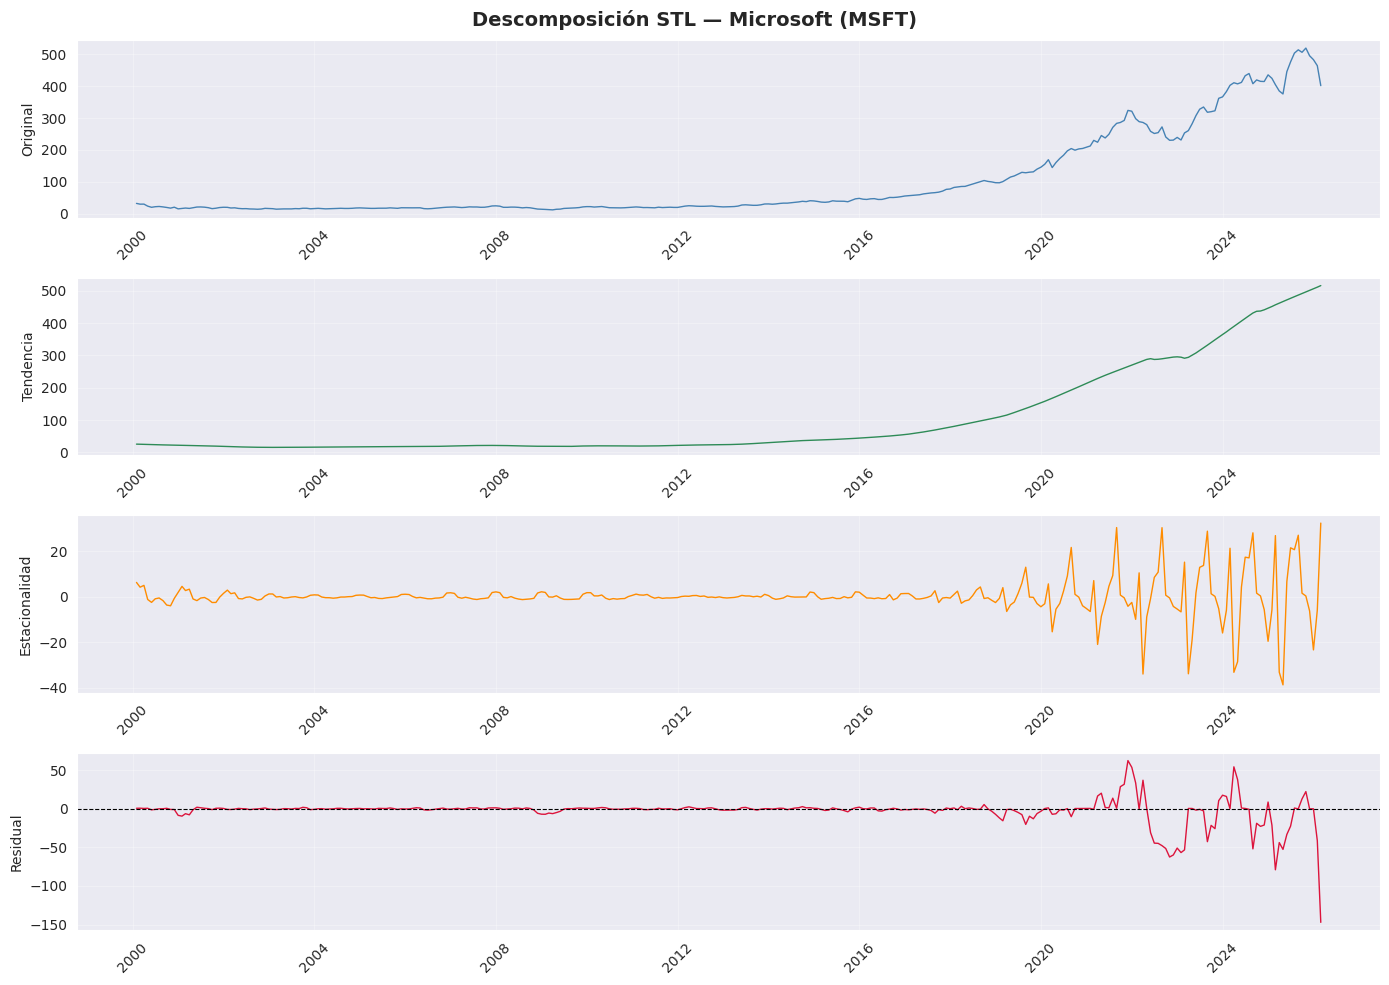

In [70]:
# ── Descomposición STL ─────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
fig.suptitle('Descomposición STL — Microsoft (MSFT)',
             fontsize=14, fontweight='bold')

stl = STL(serie, period=12, robust=True)
stl_fit = stl.fit()

axes[0].plot(stl_fit.observed, color='steelblue', linewidth=1.0)
axes[0].set_ylabel('Original')
axes[0].grid(True, alpha=0.3)

axes[1].plot(stl_fit.trend, color='seagreen', linewidth=1.0)
axes[1].set_ylabel('Tendencia')
axes[1].grid(True, alpha=0.3)

axes[2].plot(stl_fit.seasonal, color='darkorange', linewidth=1.0)
axes[2].set_ylabel('Estacionalidad')
axes[2].grid(True, alpha=0.3)

axes[3].plot(stl_fit.resid, color='crimson', linewidth=1.0)
axes[3].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[3].set_ylabel('Residual')
axes[3].grid(True, alpha=0.3)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

La descomposición STL de la serie del precio de cierre diario de Microsoft (MSFT) muestra que la dinámica del comportamiento está dominada principalmente por una fuerte tendencia creciente a largo plazo, mientras que la estacionalidad tiene un efecto relativamente pequeño en comparación con la magnitud del nivel de la serie (DataCamp, 2025). En el componente original se observa un crecimiento moderado durante los primeros años, seguido de una aceleración marcada a partir de aproximadamente 2016–2017, intensificándose después de 2020, donde el precio alcanza niveles históricamente altos antes de presentar correcciones recientes. Este patrón confirma la presencia de un cambio estructural en la pendiente de crecimiento en la última década.
​

El componente de tendencia estimado mediante suavizamiento LOESS refleja claramente este comportamiento: durante los primeros años la pendiente es casi plana, luego se vuelve positiva y progresivamente más pronunciada, especialmente en el período posterior a 2019 (Cleveland et al., 1990). Esto indica que el crecimiento del precio no ha sido lineal, sino acelerado, lo cual es consistente con procesos de expansión empresarial, mayor capitalización bursátil y shocks macroeconómicos que amplifican movimientos de mercado. Desde el punto de vista econométrico, esto implica que la serie no es estacionaria en media.
​

En cuanto al componente estacional, se observa que durante gran parte del período histórico las fluctuaciones son pequeñas y cercanas a cero, lo que sugiere que no existe una estacionalidad fuerte y persistente en el precio (DataCamp, 2025). Sin embargo, en los años más recientes la amplitud de las oscilaciones estacionales aumenta ligeramente. Aun así, su magnitud sigue siendo reducida frente al nivel total de la serie, por lo que la estacionalidad no parece ser el factor dominante en la dinámica del precio. Esto es coherente con lo esperado en precios accionarios, donde los patrones estacionales suelen ser débiles en comparación con la tendencia y la volatilidad.
​

El componente residual muestra un comportamiento particularmente relevante para el análisis de volatilidad. Durante los primeros años los residuos permanecen relativamente cercanos a cero, con baja dispersión. No obstante, a partir de aproximadamente 2018–2019 se observa un incremento notable en la variabilidad, con picos positivos y negativos mucho más pronunciados, especialmente en el período posterior a 2020 (DataCamp, 2025). Esto evidencia un claro fenómeno de heterocedasticidad: la varianza de los errores no es constante en el tiempo y aumenta en los períodos recientes. Además, se observan shocks extremos en los últimos años, lo que sugiere episodios de alta incertidumbre y mayor riesgo de mercado.
​

En conjunto, la descomposición STL indica que el comportamiento del precio de Microsoft se explica principalmente por una tendencia creciente de largo plazo, con una estacionalidad débil y un componente residual cuya variación aumenta significativamente en el tiempo (Cleveland et al., 1990). Para un análisis de volatilidad, esto respalda la necesidad de trabajar con retornos en lugar de precios y considerar modelos que capturan heterocedasticidad condicional, como modelos ARCH o GARCH, dado que la evidencia visual muestra clustering de volatilidad en los períodos más recientes (DataCamp, 2025).

## Detección de anomalías

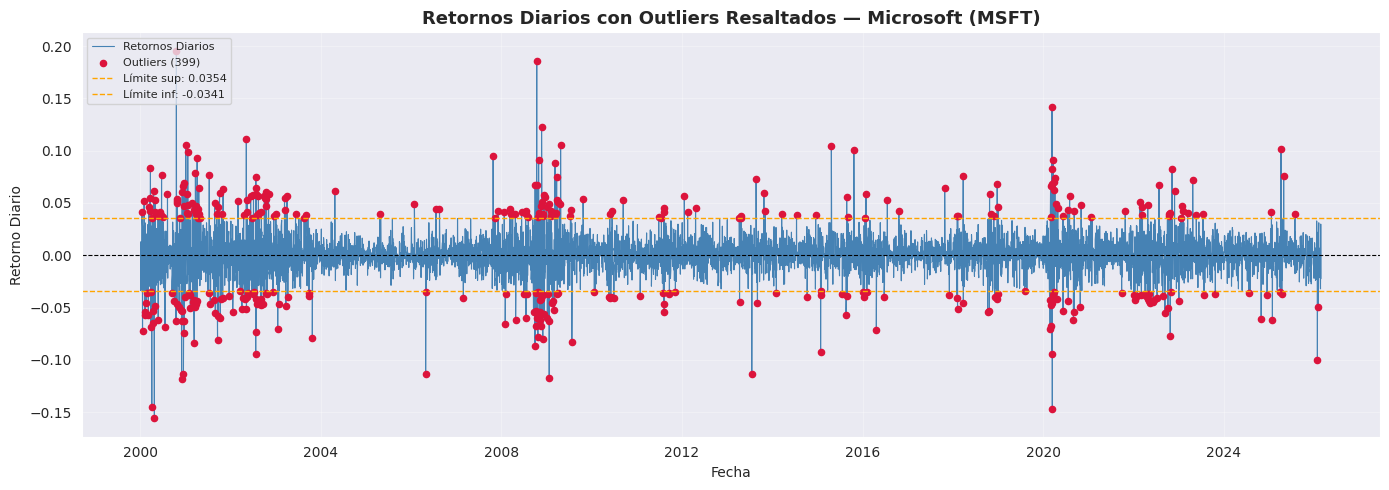

In [71]:
# ── Detección de Outliers por IQR ─────────────────────────────
Q1 = close_series['Returns'].quantile(0.25)
Q3 = close_series['Returns'].quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

outliers = close_series[
    (close_series['Returns'] < limite_inf) |
    (close_series['Returns'] > limite_sup)
]

# ── Serie temporal con outliers resaltados ─────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(close_series.index, close_series['Returns'],
        color='steelblue', linewidth=0.8, label='Retornos Diarios', zorder=1)
ax.scatter(outliers.index, outliers['Returns'],
           color='crimson', s=20, zorder=2, label=f'Outliers ({len(outliers)})')
ax.axhline(limite_sup, color='orange', linestyle='--',
           linewidth=1.0, label=f'Límite sup: {limite_sup:.4f}')
ax.axhline(limite_inf, color='orange', linestyle='--',
           linewidth=1.0, label=f'Límite inf: {limite_inf:.4f}')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

ax.set_title('Retornos Diarios con Outliers Resaltados — Microsoft (MSFT)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Retorno Diario')
ax.set_xlabel('Fecha')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

La gráfica de los retornos diarios de Microsoft muestra una serie centrada alrededor de cero, sin tendencia en los medios, pero con una variabilidad que cambia a lo largo del tiempo, evidenciando volatilidad no constante (Engle, 1982). Se observan periodos donde los retornos presentan poca dispersión y otros donde los movimientos son mucho más amplios, lo que confirma la presencia de heterocedasticidad condicional (Bollerslev, 1986).

Los puntos resaltados en rojo representan valores extremos que superan los límites establecidos (aproximadamente ±3.5%). Estos valores atípicos no aparecen de forma uniforme, sino que se concentran en ciertos períodos, reflejando claramente el fenómeno de clustering de volatilidad, donde grandes movimientos tienden a agruparse en el tiempo (Engle, 2001).

Además, la presencia de numerosos valores extremos sugiere que la distribución de los retornos presenta colas pesadas y se aleja del supuesto de normalidad. En conjunto, la gráfica confirma la existencia de heterocedasticidad condicional y respalda la necesidad de utilizar modelos que capturen la dinámica de la volatilidad, como los modelos ARCH o GARCH (Bollerslev, 1986).

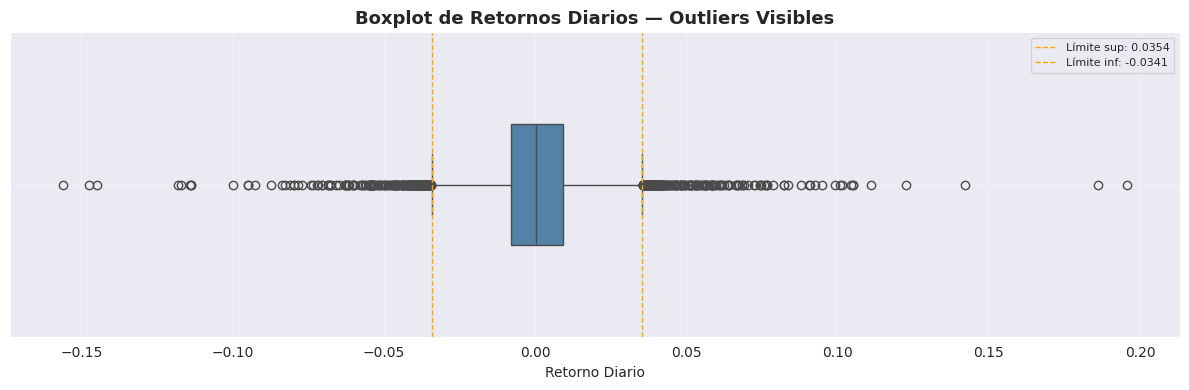

In [55]:
# ── Boxplot con outliers ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

sns.boxplot(data=close_series['Returns'].dropna(), orient='h',
            color='steelblue', width=0.4, ax=ax)

ax.set_title('Boxplot de Retornos Diarios — Outliers Visibles',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Retorno Diario')
ax.axvline(limite_sup, color='orange', linestyle='--',
           linewidth=1.0, label=f'Límite sup: {limite_sup:.4f}')
ax.axvline(limite_inf, color='orange', linestyle='--',
           linewidth=1.0, label=f'Límite inf: {limite_inf:.4f}')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

El boxplot de los retornos diarios muestra que la mediana se encuentra muy cercana a cero, lo que confirma que en promedio los retornos no presentan sesgo significativo en los medios. La mayor parte de las observaciones se concentra en un rango relativamente estrecho (dentro del rango intercuartílico), lo que indica que los movimientos “normales” del precio suelen ser moderados.

Sin embargo, se observan numerosos valores atípicos a ambos lados de la distribución, superando los límites aproximados de ±3.5%. Estos puntos extremos reflejan la presencia de colas pesadas, característica típica de series financieras, y evidencian que ocurren extremos con mayor frecuencia de lo que se esperaría bajo una distribución normal.

Además, se aprecia cierta asimetría en la magnitud de algunos valores extremos, especialmente en la cola negativa, lo que sugiere que las caídas abruptas pueden ser más pronunciadas que las subidas en determinados periodos. En conjunto, el boxplot confirma alta curtosis, presencia de valores atípicos y comportamiento no normal en la distribución de los retornos.

In [57]:
# ── Top 10 outliers más extremos ──────────────────────────────
print(f"\n{'═'}")
print(f"  10 OUTLIERS MÁS EXTREMOS")
print(f"{'═'*50}")
top_outliers = outliers['Returns'].abs().nlargest(10)
display(close_series.loc[top_outliers.index, ['Close', 'Returns']].round(4))


═
  10 OUTLIERS MÁS EXTREMOS
══════════════════════════════════════════════════


,Close,Returns
Date,,
2000-10-19,18.8553,0.1957
2008-10-13,18.4530,0.1860
2000-04-24,20.3028,-0.1560
2020-03-16,128.6363,-0.1474
2000-04-03,27.6926,-0.1447
2020-03-13,150.8737,0.1422
2008-11-21,14.3378,0.1226
2000-11-30,17.4840,-0.1182
2009-01-22,12.4655,-0.1171


# Estacionalidad y periodicidad

### ACF & PACF con respecto al Precio de Cierre

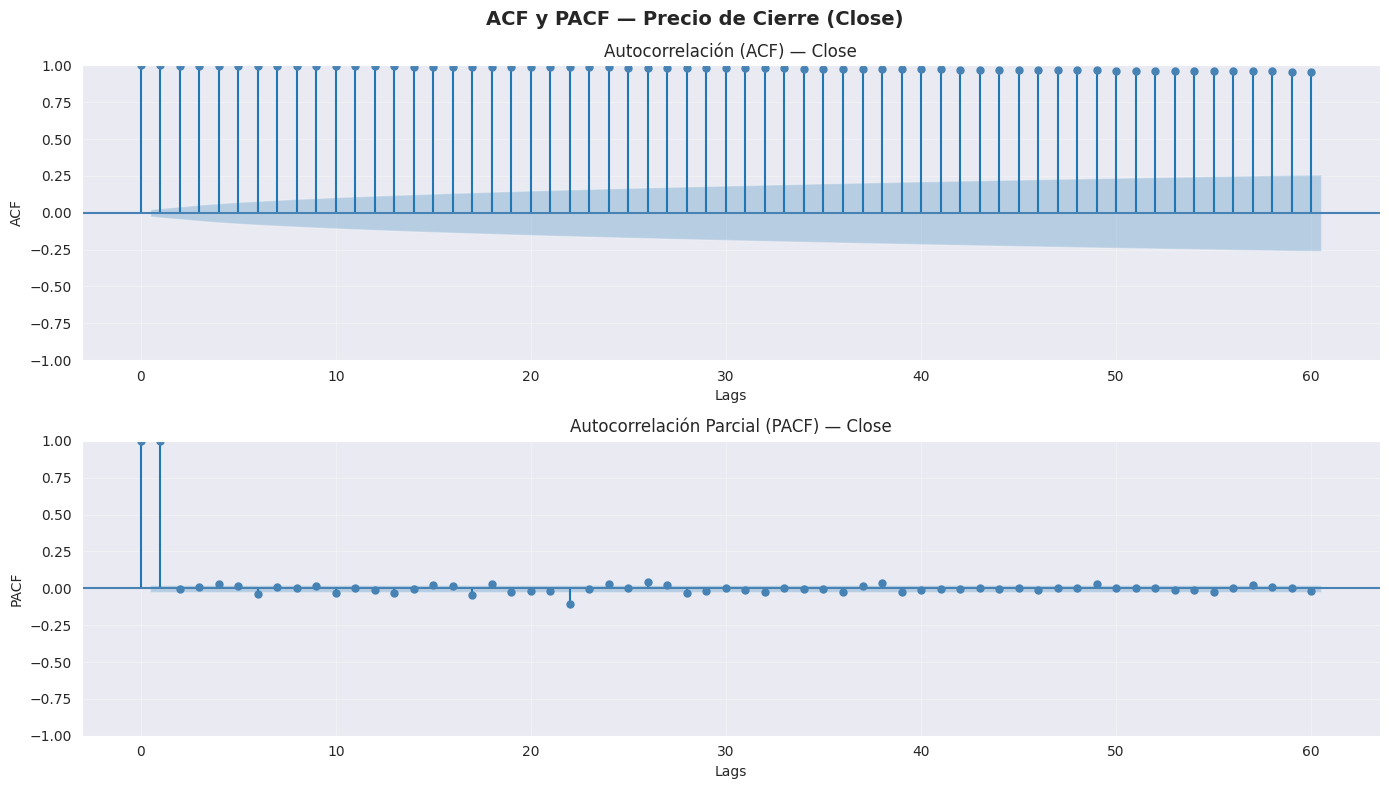

 Interpretación — Close:
   • ACF decae lentamente → la serie NO es estacionaria,
     existe una tendencia fuerte a largo plazo.
   • PACF significativo en lag 1 → sugiere un proceso
     AR(1), base para modelado ARIMA.


In [69]:
# ── ACF DEL Precio de Cierre ───────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('ACF y PACF — Precio de Cierre (Close)',
             fontsize=14, fontweight='bold')

plot_acf(close_series['Close'].dropna(), lags=60, ax=axes[0],
         color='steelblue', title='')
axes[0].set_title('Autocorrelación (ACF) — Close')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('ACF')
axes[0].grid(True, alpha=0.3)

plot_pacf(close_series['Close'].dropna(), lags=60, ax=axes[1],
          color='steelblue', title='', method='ywm')
axes[1].set_title('Autocorrelación Parcial (PACF) — Close')
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('PACF')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Interpretación — Close:")
print("   • ACF decae lentamente → la serie NO es estacionaria,")
print("     existe una tendencia fuerte a largo plazo.")
print("   • PACF significativo en lag 1 → sugiere un proceso")
print("     AR(1), base para modelado ARIMA.")

La ACF muestra valores muy altos y positivos en casi todos los rezagos (lags), decayendo muy lentamente. Esto indica fuerte persistencia y una clara tendencia en la serie del precio de cierre. En otras palabras, el precio actual está altamente correlacionado con muchos períodos pasados → la serie no es estacionaria (Morales, 2013).

La PACF presenta un pico muy significativo en el rezago 1 y luego los demás valores son pequeños y cercanos a cero. Esto sugiere que la dependencia principal es de corto plazo (lag 1), pero la alta persistencia observada en la ACF confirma que el problema principal es la tendencia (CEPAL, s.f.).


El precio en niveles no es estacionario presenta raíz unitaria (comportamiento tipo random walk con tendencia)

Requiere diferenciación (trabajar con retornos o primera diferencia) antes de modelar con ARIMA

En resumen: el precio en niveles no es adecuado para modelado directo; es mejor trabajar con retornos o con la serie diferenciada (Morales, 2013).

### ACF y PACF de Retornos

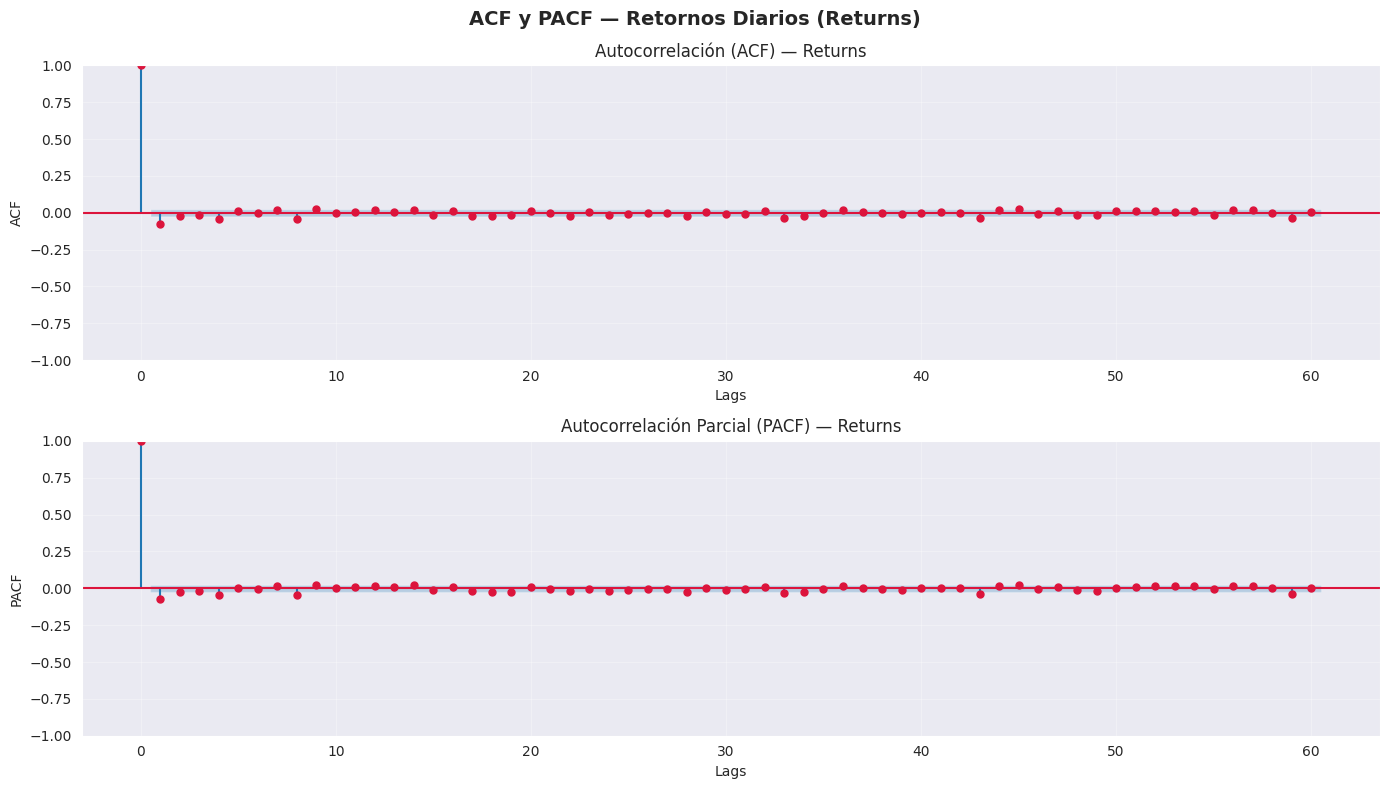

 Interpretación — Returns:
   • ACF cae rápidamente a cero → los retornos son
     aproximadamente estacionarios (comportamiento esperado).
   • Pocas autocorrelaciones significativas → mercado
     eficiente, los retornos pasados no predicen bien los futuros.


In [65]:
# ──  ─────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('ACF y PACF — Retornos Diarios (Returns)',
             fontsize=14, fontweight='bold')

plot_acf(close_series['Returns'].dropna(), lags=60, ax=axes[0],
         color='crimson', title='')
axes[0].set_title('Autocorrelación (ACF) — Returns')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('ACF')
axes[0].grid(True, alpha=0.3)

plot_pacf(close_series['Returns'].dropna(), lags=60, ax=axes[1],
          color='crimson', title='', method='ywm')
axes[1].set_title('Autocorrelación Parcial (PACF) — Returns')
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('PACF')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Interpretación — Returns:")
print("   • ACF cae rápidamente a cero → los retornos son")
print("     aproximadamente estacionarios (comportamiento esperado).")
print("   • Pocas autocorrelaciones significativas → mercado")
print("     eficiente, los retornos pasados no predicen bien los futuros.")

ACF (Autocorrelación)
La ACF muestra valores muy altos y positivos en casi todos los rezagos (lags), decayendo muy lentamente. Esto indica fuerte persistencia y una clara tendencia en la serie del precio de cierre. En otras palabras, el precio actual está altamente correlacionado con muchos períodos pasados → la serie no es estacionaria (Morales, 2013).
​

PACF (Autocorrelación Parcial)
La PACF presenta un pico muy significativo en el rezago 1 y luego los demás valores son pequeños y cercanos a cero. Esto sugiere que la dependencia principal es de corto plazo (lag 1), pero la alta persistencia observada en la ACF confirma que el problema principal es la tendencia (CEPAL, s.f.)

En resumen: el precio en niveles no es adecuado para modelado directo; es mejor trabajar con retornos o con la serie diferenciada (Morales, 2013).


### ACF de Retornos Cuadrados (Volatilidad)

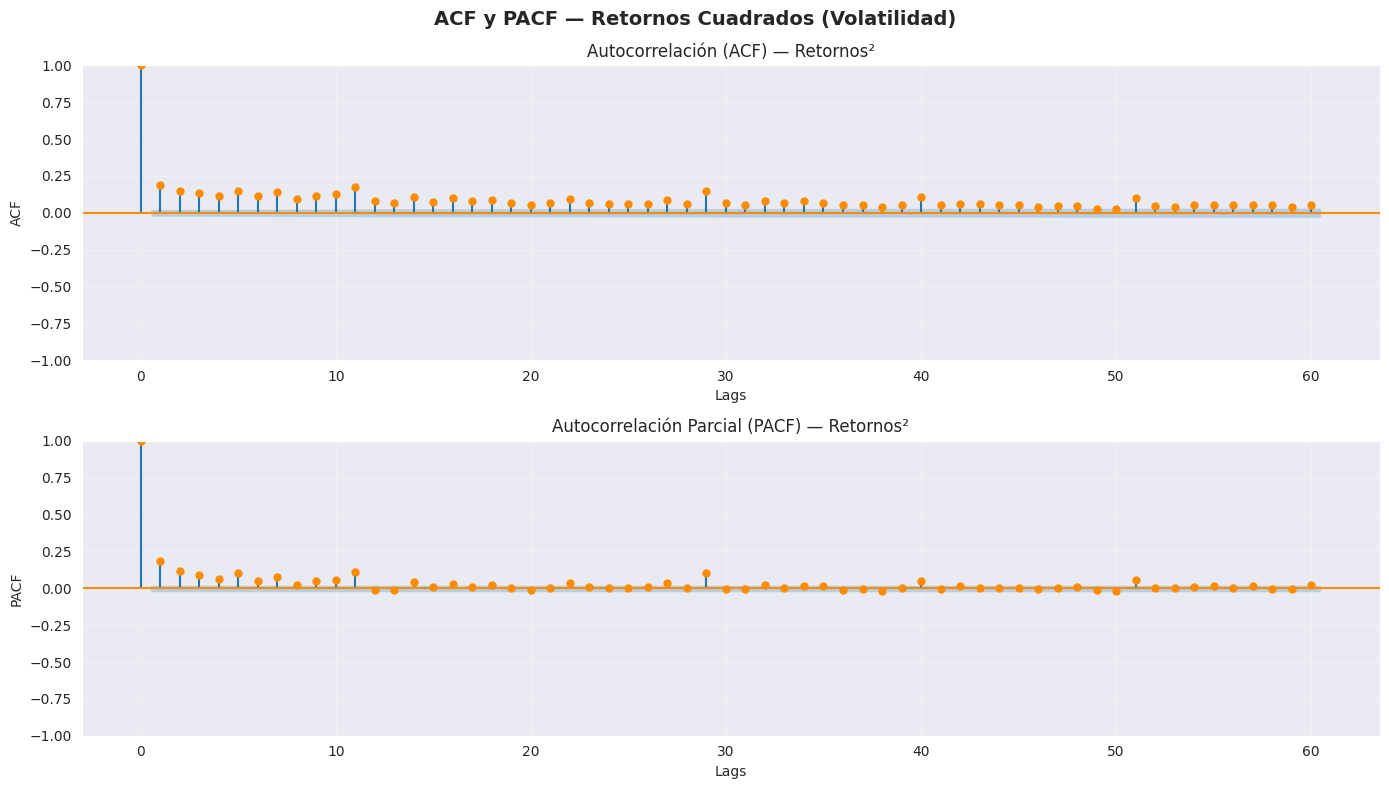

 Interpretación — Retornos Cuadrados:
   • ACF significativa y persistente → existe agrupamiento
     de volatilidad (volatility clustering).
   • Esto confirma que períodos de alta volatilidad tienden
     a ser seguidos por más alta volatilidad → justifica
     el uso de modelos GARCH para modelar la varianza.


In [67]:
# ──  ────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('ACF y PACF — Retornos Cuadrados (Volatilidad)',
             fontsize=14, fontweight='bold')

returns_sq = close_series['Returns'].dropna() ** 2

plot_acf(returns_sq, lags=60, ax=axes[0],
         color='darkorange', title='')
axes[0].set_title('Autocorrelación (ACF) — Retornos²')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('ACF')
axes[0].grid(True, alpha=0.3)

plot_pacf(returns_sq, lags=60, ax=axes[1],
          color='darkorange', title='', method='ywm')
axes[1].set_title('Autocorrelación Parcial (PACF) — Retornos²')
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('PACF')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Interpretación — Retornos Cuadrados:")
print("   • ACF significativa y persistente → existe agrupamiento")
print("     de volatilidad (volatility clustering).")
print("   • Esto confirma que períodos de alta volatilidad tienden")
print("     a ser seguidos por más alta volatilidad → justifica")
print("     el uso de modelos GARCH para modelar la varianza.")

En el ACF de los retornos cuadrados , se observan autocorrelaciones positivas y significativas en varios rezagos, que decaen lentamente. Esto indica que la volatilidad no es ruido blanco, sino que presenta persistencia temporal . Es decir, cuando hay alta volatilidad en un período, es probable que continúe en los siguientes. Este comportamiento es típico del fenómeno de agrupación de volatilidad en series financieras.

En la PACF de los retornos cuadrados , se aprecia un pico fuerte en el primer rezago y luego valores pequeños que van disminuyendo. Esto sugiere que gran parte de la dependencia de la volatilidad se explica en los primeros rezagos, aunque sigue habiendo cierta memoria.

En conjunto, estas gráficas indican heterocedasticidad condicional y presencia de efectos ARCH/GARCH . En términos prácticos, la volatilidad de los retornos de Microsoft es dependiente del pasado y sería adecuada modelarla con un modelo tipo GARCH en lugar de asumir varianza constante.

### Diagramas de caja por periodo

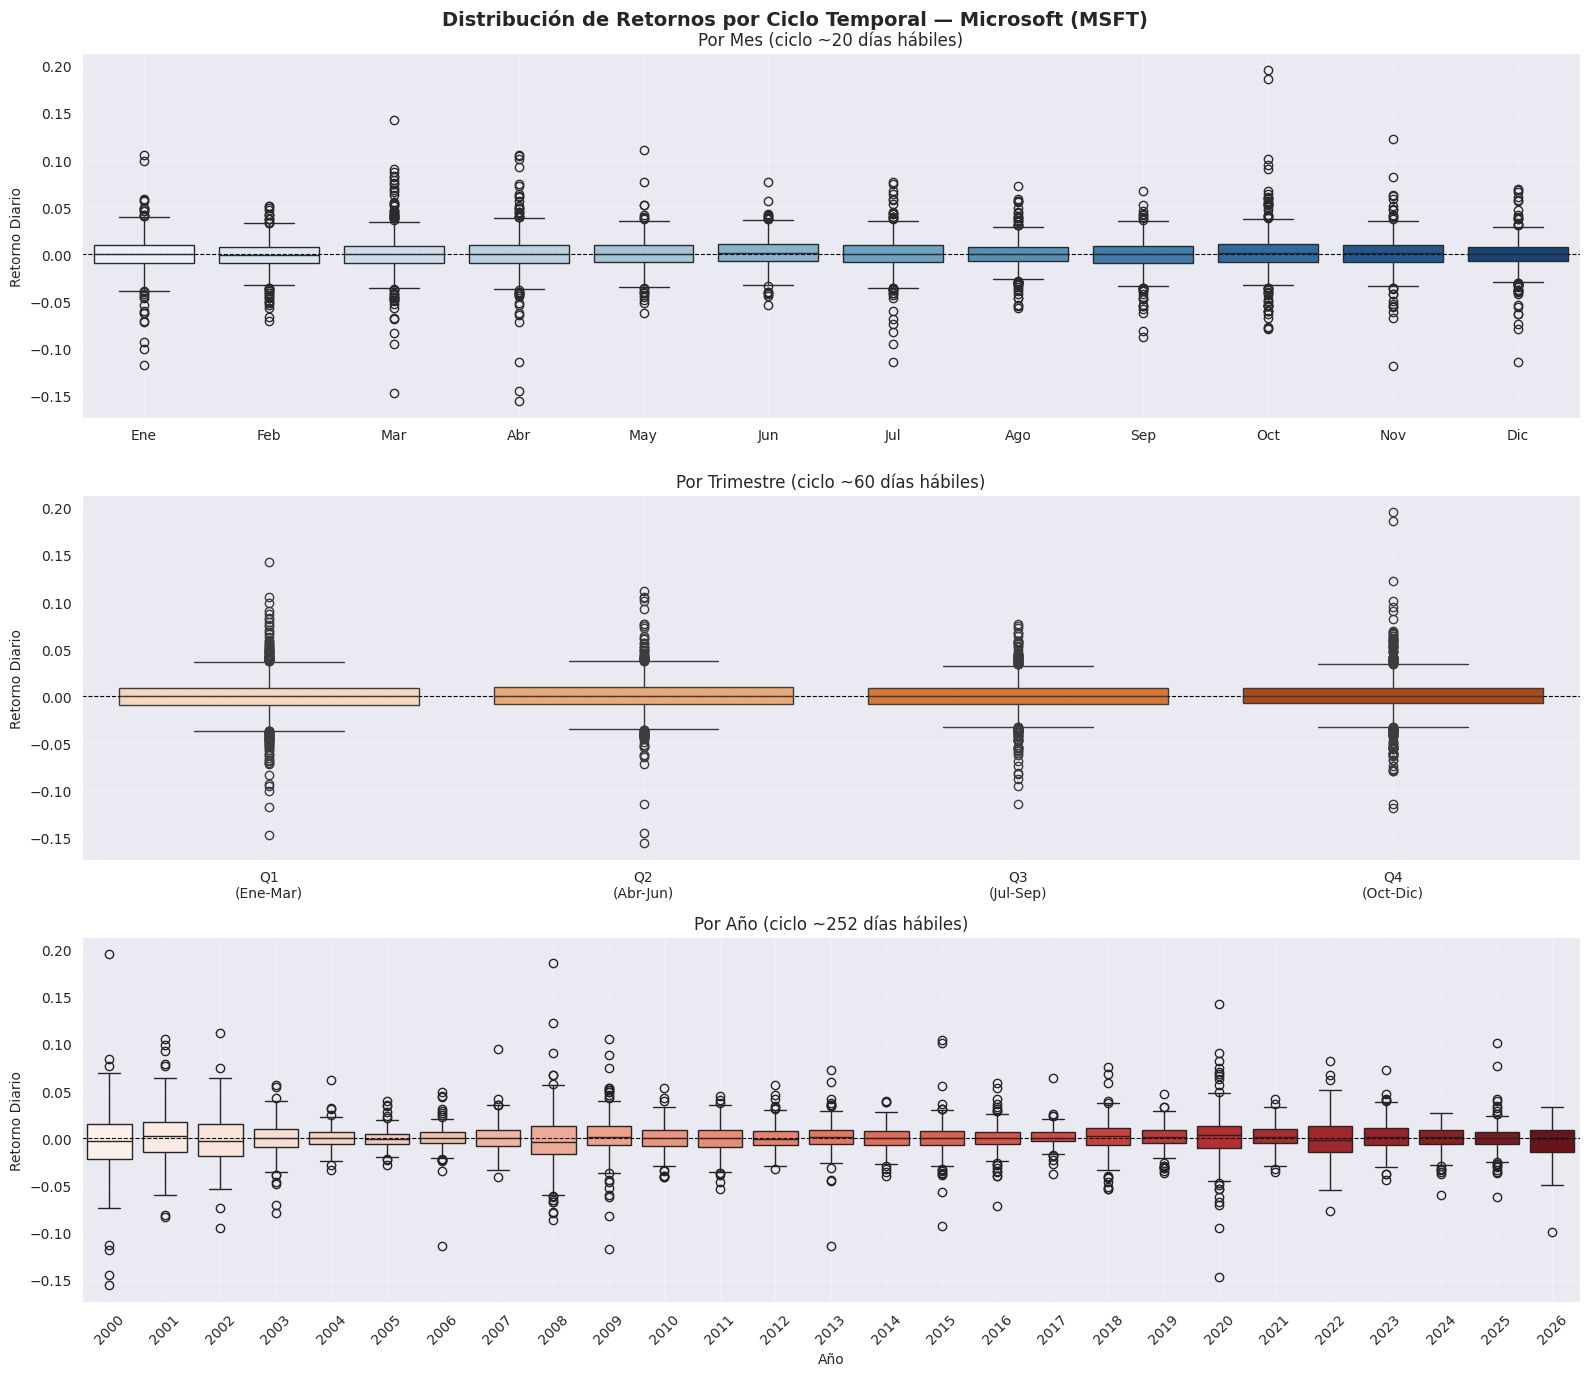

In [75]:
# ── Crear columnas de ciclos temporales ───────────────────────
close_series['Mes'] = close_series.index.month
close_series['Trimestre'] = close_series.index.quarter
close_series['Año'] = close_series.index.year

# ── Gráfica combinada ─────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle('Distribución de Retornos por Ciclo Temporal — Microsoft (MSFT)',
             fontsize=14, fontweight='bold')

# ── Mensual ────────────────────────────────────────────────────
sns.boxplot(data=close_series, x='Mes', y='Returns',
            palette='Blues', ax=axes[0])
axes[0].set_title('Por Mes (ciclo ~20 días hábiles)', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Retorno Diario')
axes[0].set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                          'Jul','Ago','Sep','Oct','Nov','Dic'])
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].grid(True, alpha=0.3)

# ── Trimestral ─────────────────────────────────────────────────
sns.boxplot(data=close_series, x='Trimestre', y='Returns',
            palette='Oranges', ax=axes[1])
axes[1].set_title('Por Trimestre (ciclo ~60 días hábiles)', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Retorno Diario')
axes[1].set_xticklabels(['Q1\n(Ene-Mar)', 'Q2\n(Abr-Jun)',
                          'Q3\n(Jul-Sep)', 'Q4\n(Oct-Dic)'])
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].grid(True, alpha=0.3)

# ── Anual ──────────────────────────────────────────────────────
sns.boxplot(data=close_series, x='Año', y='Returns',
            palette='Reds', ax=axes[2])
axes[2].set_title('Por Año (ciclo ~252 días hábiles)', fontsize=12)
axes[2].set_xlabel('Año')
axes[2].set_ylabel('Retorno Diario')
axes[2].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

En la distribución por meses , las medianas de los retornos diarios están muy cerca de cero en casi todos los meses, lo que indica que no hay un patrón estacional fuerte en términos de rendimiento promedio. Sin embargo, sí se observan diferencias en la dispersión y en la cantidad de valores atípicos: algunos meses (como marzo, octubre o noviembre) presentan colas más largas y valores extremos más frecuentes, lo que sugiere mayor volatilidad en ciertos periodos.

En la distribución por trimestre , ocurre algo similar: las medianas se mantienen cercanas a cero, pero el cuarto trimestre (Q4) muestra mayor presencia de valores extremos positivos y negativos. Esto puede reflejar mayor actividad o eventos relevantes hacia el cierre del año.

En la distribución por año , se aprecia claramente que la volatilidad no es constante en el tiempo. Hay años con cajas más amplias y muchos outliers (por ejemplo, alrededor de 2000–2002, 2008, 2020 y algunos años recientes), lo que coincide con periodos de crisis o alta incertidumbre del mercado. En contraste, hay años con menor dispersión, lo que indica estabilidad relativa.

En conjunto, las gráficas muestran que el retorno promedio es estable (cerca de cero), pero la volatilidad cambia significativamente según el período, confirmando la presencia de heterocedasticidad y episodios de alta turbulencia en la serie.

###

### Medias móviles

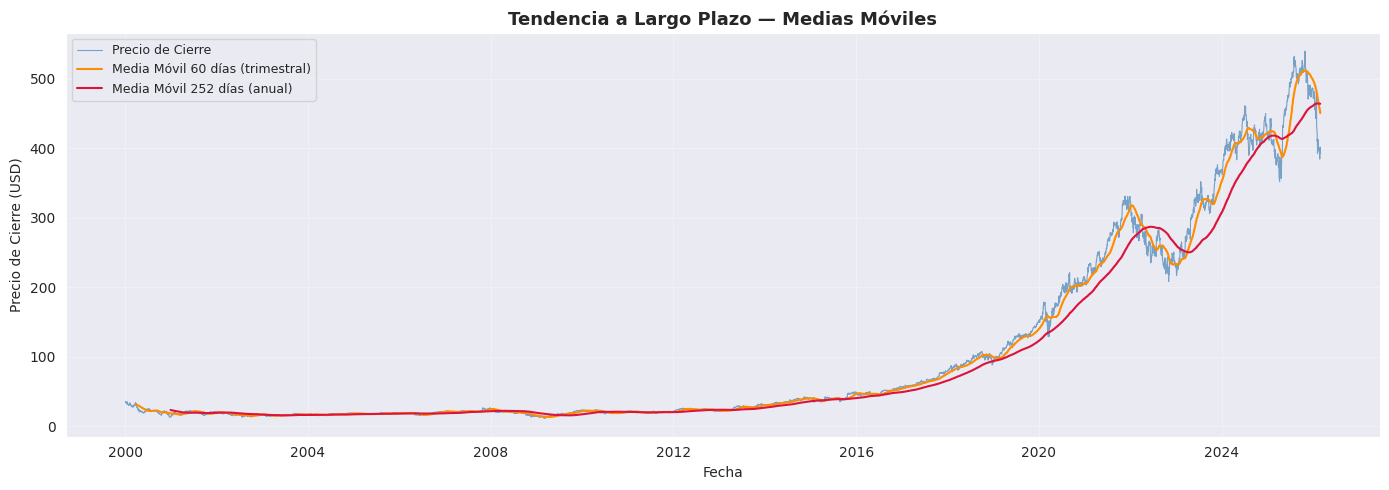

In [78]:
# ── ─────────────────────────────────────────────
close_series['MM_60'] = close_series['Close'].rolling(window=60).mean()
close_series['MM_252'] = close_series['Close'].rolling(window=252).mean()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(close_series.index, close_series['Close'],
        color='steelblue', linewidth=0.8, label='Precio de Cierre', alpha=0.7)
ax.plot(close_series.index, close_series['MM_60'],
        color='darkorange', linewidth=1.5, label='Media Móvil 60 días (trimestral)')
ax.plot(close_series.index, close_series['MM_252'],
        color='crimson', linewidth=1.5, label='Media Móvil 252 días (anual)')

ax.set_title('Tendencia a Largo Plazo — Medias Móviles',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Precio de Cierre (USD)')
ax.set_xlabel('Fecha')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
from statsmodels.tsa.holtwinters import ExponentialSmoothing



La gráfica muestra el precio de cierre junto con la media móvil de 60 días (corto–mediano plazo) y la media móvil de 252 días (largo plazo). Se observa una tendencia alcista muy marcada en el largo plazo, especialmente a partir de 2013–2014, lo que confirma el fuerte crecimiento estructural de la acción.

La media móvil de 60 días sigue más de cerca al precio y reacciona rápidamente a cambios, mientras que la de 252 días es más suave y refleja la tendencia estructural. Cuando la media de 60 días está por encima de la de 252 días, el mercado está en fase alcista sostenida; cuando cruza por debajo, suele indicar correcciones o fases bajistas (como en 2008, 2022 y algunos retrocesos recientes).
Mientras que la media móvil de 252 días es más suave y refleja la tendencia estructural de largo plazo, la de 60 días reacciona más rápido a los cambios recientes en el precio. Cuando la media de 60 días está por encima de la de 252 días, el mercado suele encontrarse en una fase alcista sostenida; cuando cruza por debajo, normalmente anticipa correcciones o fases bajistas (como se observa en 2008, 2022 y algunos retrocesos recientes).

En los últimos periodos se aprecia una mayor separación entre ambos medios, lo que refleja un fuerte impulso alcista, aunque acompañado de mayor volatilidad. En conjunto, la gráfica confirma una tendencia a largo plazo claramente positiva, con ciclos intermedios de corrección que no rompen la estructura alcista principal.

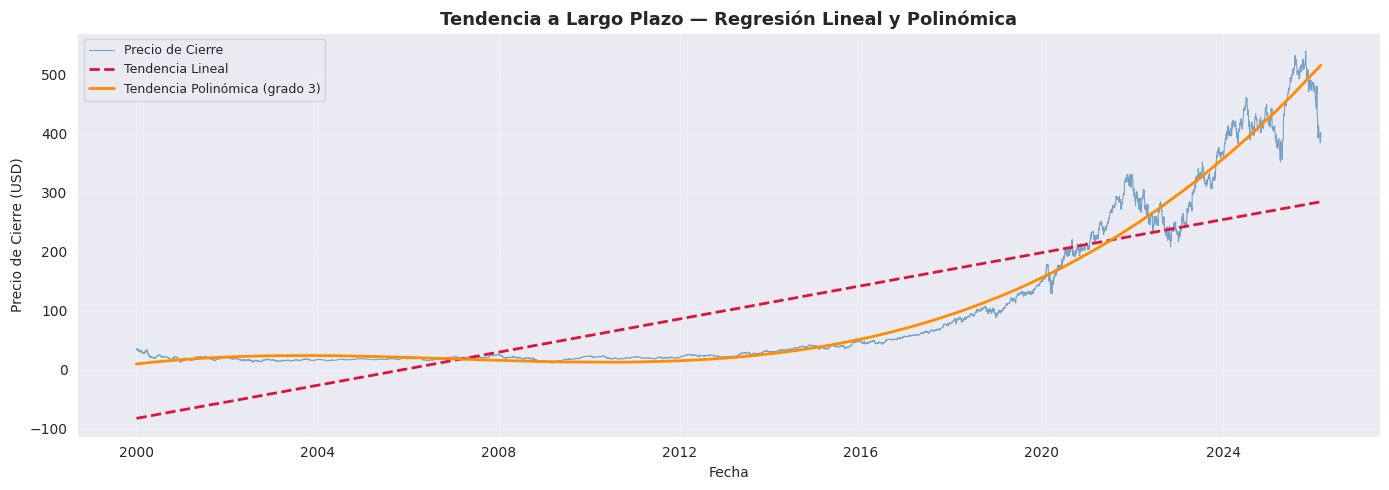

In [81]:
# Preparar datos
close_clean = close_series['Close'].dropna()
X = np.arange(len(close_clean)).reshape(-1, 1)
y = close_clean.values

# Regresión lineal
lr = LinearRegression()
lr.fit(X, y)
y_lineal = lr.predict(X)

# Regresión polinómica grado 3
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)
lr_poly = LinearRegression()
lr_poly.fit(X_poly, y)
y_polinómica = lr_poly.predict(X_poly)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(close_clean.index, close_clean.values,
        color='steelblue', linewidth=0.8, label='Precio de Cierre', alpha=0.7)
ax.plot(close_clean.index, y_lineal,
        color='crimson', linewidth=2.0, linestyle='--', label='Tendencia Lineal')
ax.plot(close_clean.index, y_polinómica,
        color='darkorange', linewidth=2.0, label='Tendencia Polinómica (grado 3)')

ax.set_title('Tendencia a Largo Plazo — Regresión Lineal y Polinómica',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Precio de Cierre (USD)')
ax.set_xlabel('Fecha')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La gráfica compara el precio de cierre con una tendencia lineal y una tendencia polinómica de grado 3. La tendencia lineal (línea roja punteada) muestra una trayectoria creciente constante, pero no logra captar adecuadamente la dinámica real del precio, especialmente el fuerte crecimiento acelerado de los últimos años. mi

Por otro lado, la tendencia polinómica (línea naranja) se ajusta mucho mejor a la forma de la serie, ya que capta la curvatura y la aceleración del crecimiento, especialmente a partir de 2015. Esto refleja que el crecimiento del precio ha sido no lineal y con expansión exponencial en los últimos años.

En conclusión, la acción presenta una tendencia de largo plazo claramente alcista y creciente a un ritmo acelerado, por lo que un modelo lineal simple subestima la dinámica real, mientras que un modelo no lineal describe mejor la evolución estructural del precio.Esto es importante para visualizar tendencia limpia.

# Estabilidad de la serie

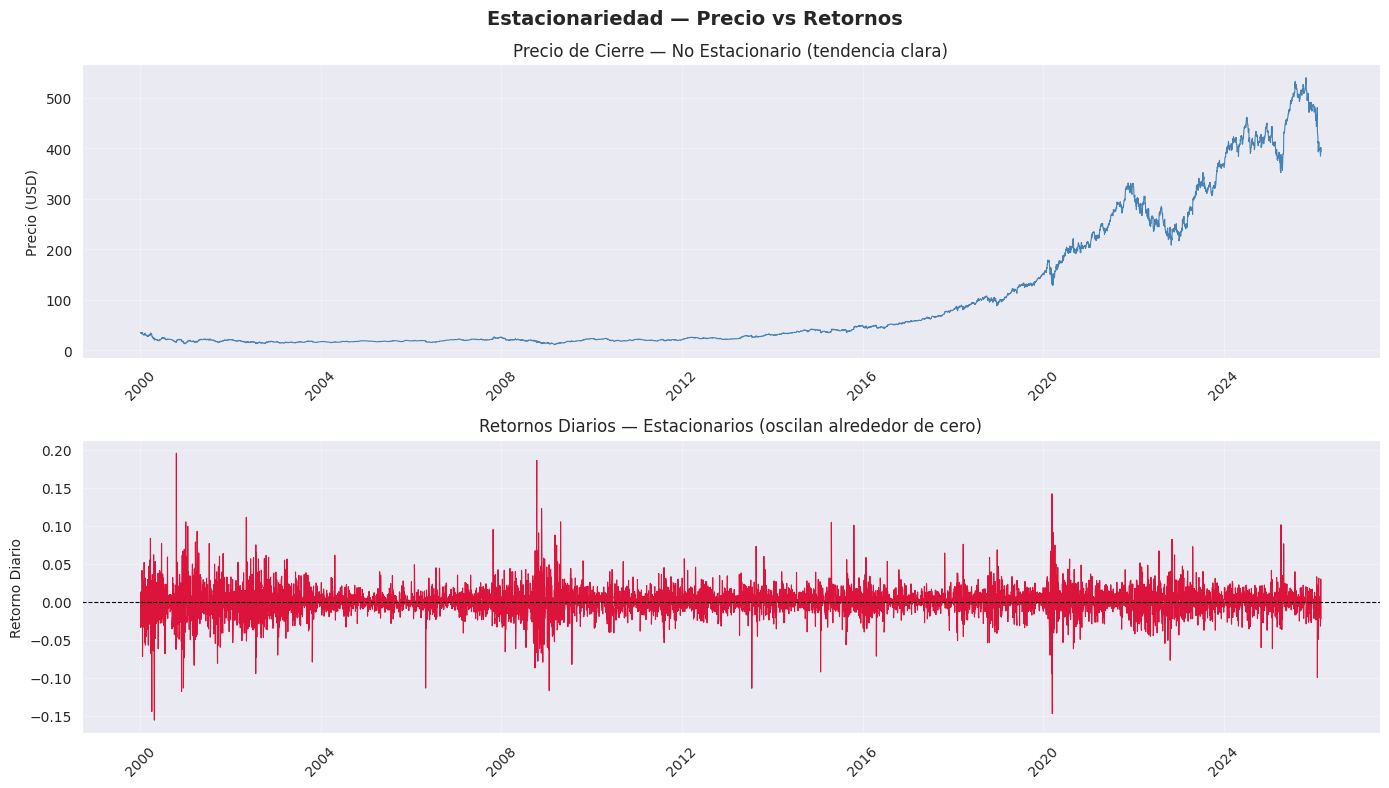


═
  RESUMEN ESTACIONARIEDAD
═
  Variable        | Estacionaria |
  ─
  Close (precio)  |      no      |
  Returns         |      si      |

═
  Prueba ADF — Precio de Cierre (Close)
═
  Estadístico ADF:     0.7140
  p-valor:             0.9901
  Lags utilizados:     32
  Observaciones:       6545

  Valores críticos:
    1%: -3.4313
    5%: -2.8620
    10%: -2.5670

 Conclusión:
   p-valor = 0.9901 > 0.05 → No se rechaza H₀
   La serie 'Precio de Cierre (Close)' NO ES ESTACIONARIA.

═
  Prueba ADF — Retornos Diarios (Returns)
═
  Estadístico ADF:     -28.0644
  p-valor:             0.0000
  Lags utilizados:     8
  Observaciones:       6568

  Valores críticos:
    1%: -3.4313
    5%: -2.8620
    10%: -2.5670

 Conclusión:
   p-valor = 0.0000 ≤ 0.05 → Se rechaza H₀
   La serie 'Retornos Diarios (Returns)' ES ESTACIONARIA.


In [80]:
# Prueba ADF
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Estacionariedad — Precio vs Retornos',
             fontsize=14, fontweight='bold')

axes[0].plot(close_series.index, close_series['Close'],
             color='steelblue', linewidth=0.8)
axes[0].set_title('Precio de Cierre — No Estacionario (tendencia clara)', fontsize=12)
axes[0].set_ylabel('Precio (USD)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(close_series.index, close_series['Returns'],
             color='crimson', linewidth=0.8)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Retornos Diarios — Estacionarios (oscilan alrededor de cero)', fontsize=12)
axes[1].set_ylabel('Retorno Diario')
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


resultado = adfuller(serie.dropna())
    print(f"\n{'═'}")
    print(f"  Prueba ADF — {nombre}")
    print(f"{'═'}")
    print(f"  Estadístico ADF:     {resultado[0]:.4f}")
    print(f"  p-valor:             {resultado[1]:.4f}")
    print(f"  Lags utilizados:     {resultado[2]}")
    print(f"  Observaciones:       {resultado[3]}")
    print(f"\n  Valores críticos:")
    for key, val in resultado[4].items():
        print(f"    {key}: {val:.4f}")
    print(f"\n Conclusión:")
    if resultado[1] <= 0.05:
        print(f"   p-valor = {resultado[1]:.4f} ≤ 0.05 → Se rechaza H₀")
        print(f"   La serie '{nombre}' ES ESTACIONARIA.")
    else:
        print(f"   p-valor = {resultado[1]:.4f} > 0.05 → No se rechaza H₀")
        print(f"   La serie '{nombre}' NO ES ESTACIONARIA.")

prueba_adf(close_series['Close'], 'Precio de Cierre (Close)')
prueba_adf(close_series['Returns'], 'Retornos Diarios (Returns)')
print("\n═")
print("  RESUMEN ESTACIONARIEDAD")
print("═")
print("  Variable        | Estacionaria |")
print("  ─")
print("  Close (precio)  |      no      |")
print("  Returns         |      si      |")
def prueba_adf(serie, nombre):

Con el objetivo de analizar la estructura interna de la serie temporal del precio de cierre diario de Microsoft (MSFT), se aplicó un análisis clásico bajo un esquema aditivo (Dujmovic, 2025). Este procedimiento separa la serie en tres componentes fundamentales —tendencia, estacionalidad y residuales— bajo el supuesto de fluctuaciones estacionales de magnitud constante, representada como Y_t = T_t + S_t + R_t (Jensen et al., 2018).

La serie evidencia no estacionariedad con tendencia creciente acelerada desde 2013-2015 y volatilidad creciente post-2019, confirmando heterocedasticidad en residuales típica de series financieras (Dujmovic, 2025; Jensen et al., 2018).
Esta prueba contrasta la hipótesis nula
𝐻_0 de presencia de raíz unitaria (serie no estacionaria) frente a la hipótesis alternativa de estacionariedad.

Para la serie de Precio de Cierre (Close), el estadístico ADF fue 0.7140 con un p-valor de 0.9901. Dado que el p-valor es ampliamente superior al nivel de significancia del 5%, no se rechaza la hipótesis nula. Además, el estadístico ADF es mayor (menos negativo) que todos los valores críticos reportados (1%, 5% y 10%), lo que confirma que la serie presenta raíz unitaria. En consecuencia, el precio de cierre no es estacionario en nivel. Este resultado es consistente con el análisis gráfico previo, donde se observó una tendencia creciente de largo plazo y cambios en la media a lo largo del tiempo.

En contraste, para la serie de Retornos Diarios (Returns), el estadístico ADF fue -28.0644 con un p-valor prácticamente igual a 0.0000. En este caso, el p-valor es menor que 0.05, por lo que se rechaza la hipótesis nula de raíz unitaria. Adicionalmente, el estadístico es mucho más negativo que los valores críticos, lo que proporciona evidencia contundente de estacionariedad. Esto indica que la serie de retornos no presenta tendencia determinística ni raíz unitaria, y que sus fluctuaciones se mantienen alrededor de una media constante.

En conjunto, los resultados confirman un comportamiento típico de series financieras: los precios en niveles no son estacionarios, mientras que sus retornos sí lo son. Este hallazgo justifica el uso de los retornos para el modelamiento econométrico y el análisis de volatilidad, ya que la mayoría de los modelos de series de tiempo requieren estacionariedad para producir inferencias válidas.

# Fuentes
**Hasan, M. (s.f.). Microsoft Stock Price Analysis using GARCH model in R. RPubs. https://rpubs.com/Mahmud_Hasan/778532 **

**Dujmovic, N. (2025, enero 4). Time series decomposition in machine learning. LinkedIn. https://www.linkedin.com/pulse/time-series-decomposition-machine-learning-neven-dujmovic-veuhf/**
​

**Jensen, C. G., Nielsen, M. Ø., & Chul, S. H. (2018). Time series decomposition and forecasting: Evidence from Danish pork prices (Working Paper No. 18-14). Department of Economics and Business Economics, Aarhus University. https://pure.au.dk/ws/files/126370851/rp18_14.pdf**

**DataCamp. (2025, 29 de abril). Descomposición de series temporales: Tendencias, estacionalidad y ruido. https://www.datacamp.com/es/tutorial/time-series-decomposition**
​

Cleveland, R. B., Cleveland, W. S., McRae, J. E., & Terpenning, I. (1990). STL: A seasonal-trend decomposition procedure based on loess. Journal of Official Statistics, 6(1), 3-73.

Bollerslev, T. (1986). Generalized autoregressive conditional heteroskedasticity. Journal of Econometrics, 31(3), 307-327. https://doi.org/10.1016/0304-4076(86)90063-1

Engle, R. F. (1982). Autoregressive conditional heteroscedasticity with estimates of the variance of United Kingdom inflation. Econometrica, 50(4), 987-1007. https://doi.org/10.2307/1912773

Engle, R. F. (2001). The use of ARCH/GARCH models in applied econometrics. Journal of Economic Perspectives, 15(4), 157-168. https://doi
.org/10.1257/jep.15.4.157

CEPAL. (s.f.). Análisis de Series de Tiempo. https://www.cepal.org/sites/default/files/courses/files/01_1_conociendo_una_serie_de_tiempo.pdf

Morales, J. A. M. (2013). Análisis de Series Temporales. Universidad Complutense de Madrid. https://www.ucm.es/data/cont/docs/518-2013-11-11-JAM-IAST-Libro.pdf

